# Bivariate Analysis

Bivariate analysis examines the statistical relationship between **two variables** simultaneously.

In this notebook, we explore the three major combinations:
1. **Numerical + Numerical:** Scatter plots, relationship types, line plots, and pair plots
2. **Numerical + Categorical:** Bar plots, box plots, grouped KDEs, and the critical Bar vs. Box comparison
3. **Categorical + Categorical:** Crosstabs, raw counts vs. row percentages, heatmaps, and clustermaps

---


## 1. Setup & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

df = pd.read_csv('../../data/titanic.csv')
print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2. Numerical + Numerical Analysis

When exploring two continuous/numerical variables, we investigate:
- Direction of relationship (positive, negative, or none)
- Strength and linearity
- Clusters or outlier pairings


### 2.1 Scatter Plot (`Age` vs. `Fare`)

A scatter plot maps each observation as a coordinate $(X, Y)$ on Cartesian axes.


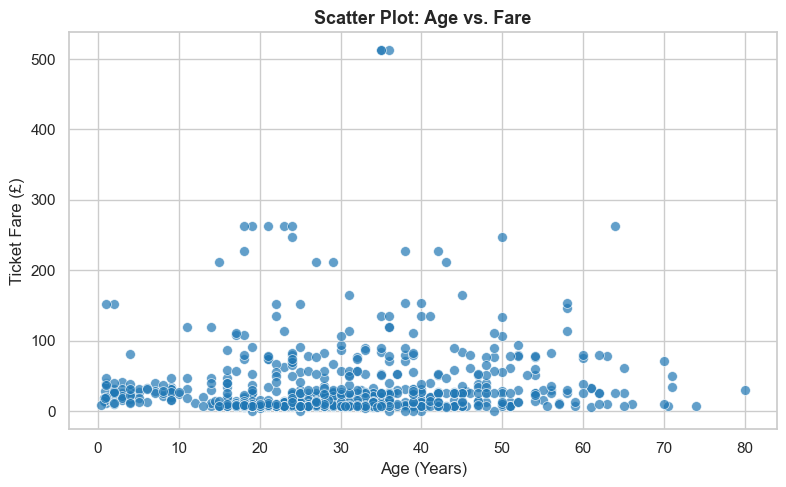

In [2]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df, 
    x='Age', 
    y='Fare', 
    alpha=0.7, 
    color='#1f77b4', 
    edgecolor='w', 
    s=50
)

plt.title('Scatter Plot: Age vs. Fare', fontsize=13, weight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Ticket Fare (£)')
plt.tight_layout()

# Save plot
plt.savefig('../../outputs/plots/bivariate_scatter_age_fare.png', dpi=150)
plt.show()


### Observation
- The majority of passengers (regardless of age) paid fares below £100.
- Extreme luxury fares (> £200) occurred primarily among passengers aged 20 to 60.
- Overall linear correlation between `Age` and `Fare` is weak ($r \approx 0.096$).


### 2.2 Understanding Relationship Types: Positive, Negative, and None

Let us compare three distinct feature pairs side-by-side:
1. **Positive Tendency:** `SibSp` vs `Parch` (family members traveling together)
2. **Negative Tendency:** `Pclass` vs `Fare` (higher class number = lower fare)
3. **No Obvious Relationship:** `PassengerId` vs `Age` (arbitrary ID sequence)


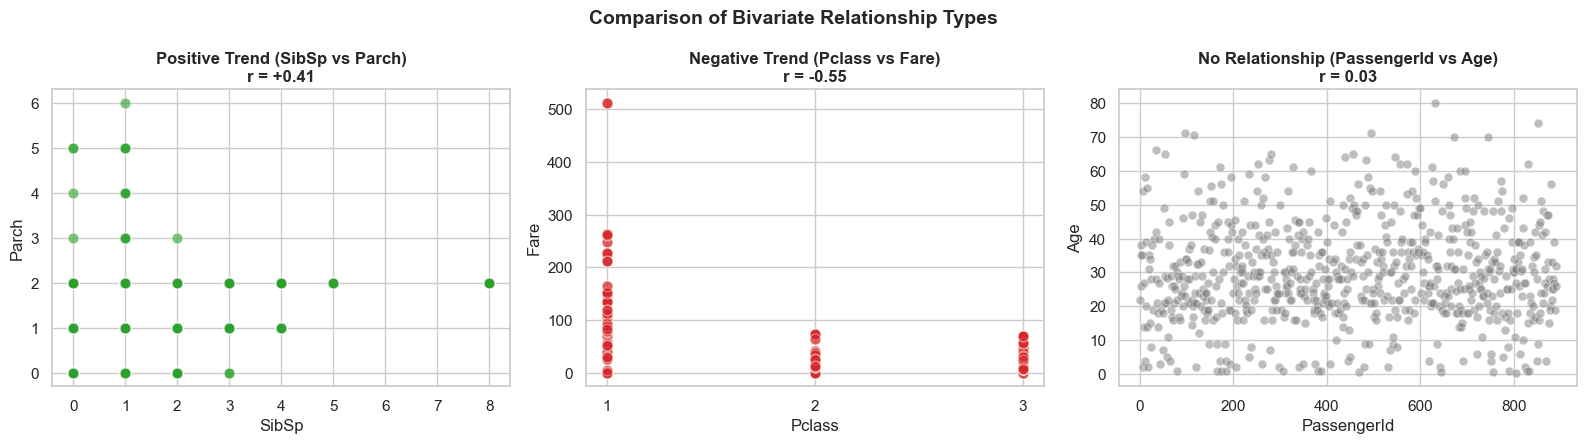

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Positive relationship tendency
sns.scatterplot(data=df, x='SibSp', y='Parch', ax=axes[0], color='#2ca02c', alpha=0.6, s=60)
axes[0].set_title('Positive Trend (SibSp vs Parch)\nr = +0.41', weight='bold')

# Negative relationship tendency
sns.scatterplot(data=df, x='Pclass', y='Fare', ax=axes[1], color='#d62728', alpha=0.5, s=60)
axes[1].set_title('Negative Trend (Pclass vs Fare)\nr = -0.55', weight='bold')
axes[1].set_xticks([1, 2, 3])

# No relationship
sns.scatterplot(data=df, x='PassengerId', y='Age', ax=axes[2], color='#7f7f7f', alpha=0.5, s=40)
axes[2].set_title('No Relationship (PassengerId vs Age)\nr = 0.03', weight='bold')

plt.suptitle('Comparison of Bivariate Relationship Types', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


### Observation
- **`SibSp` vs `Parch`**: Demonstrates positive covariance; passengers with many siblings/spouses also tend to have more children/parents aboard.
- **`Pclass` vs `Fare`**: Demonstrates negative covariance; as class number increases (from 1st to 3rd), ticket fare plummets.
- **`PassengerId` vs `Age`**: Demonstrates zero correlation; data points are randomly dispersed with a flat horizontal pattern.


### 2.3 Line Plot (`sns.lineplot`)

Line plots are ideal when the X-variable has an ordered sequence or when tracking an aggregated trend across continuous intervals.
Seaborn automatically computes the **mean** and shades a **95% bootstrapped confidence interval**.


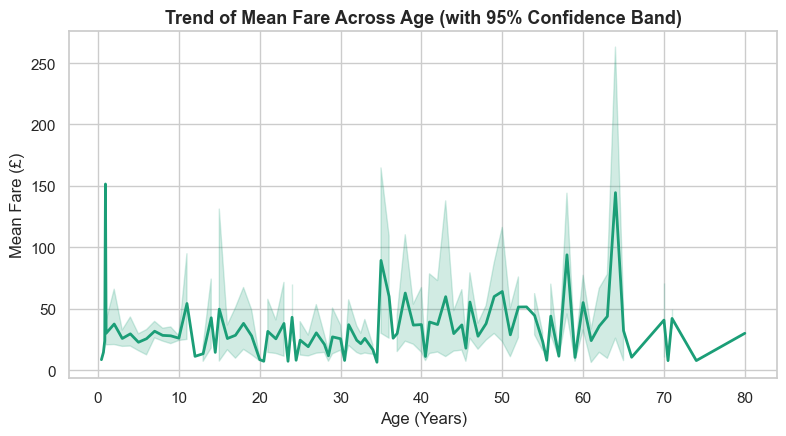

In [4]:
# Create Age brackets of 5 years to show clean trend lines
df['AgeBracket'] = pd.cut(df['Age'], bins=range(0, 85, 10))

plt.figure(figsize=(8, 4.5))
sns.lineplot(data=df, x='Age', y='Fare', color='#1b9e77', linewidth=2)

plt.title('Trend of Mean Fare Across Age (with 95% Confidence Band)', fontsize=13, weight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Mean Fare (£)')
plt.tight_layout()
plt.show()


### Observation
The line plot shows that average fare paid peaks around ages 35-40 and around 60 (peak earning/wealth stages in life), with wide confidence bands at older ages due to fewer passengers.


### 2.4 Pair Plot (`sns.pairplot`)

A **Pair Plot** computes all pairwise bivariate scatter plots across numerical features simultaneously, placing univariate histograms along the diagonal.


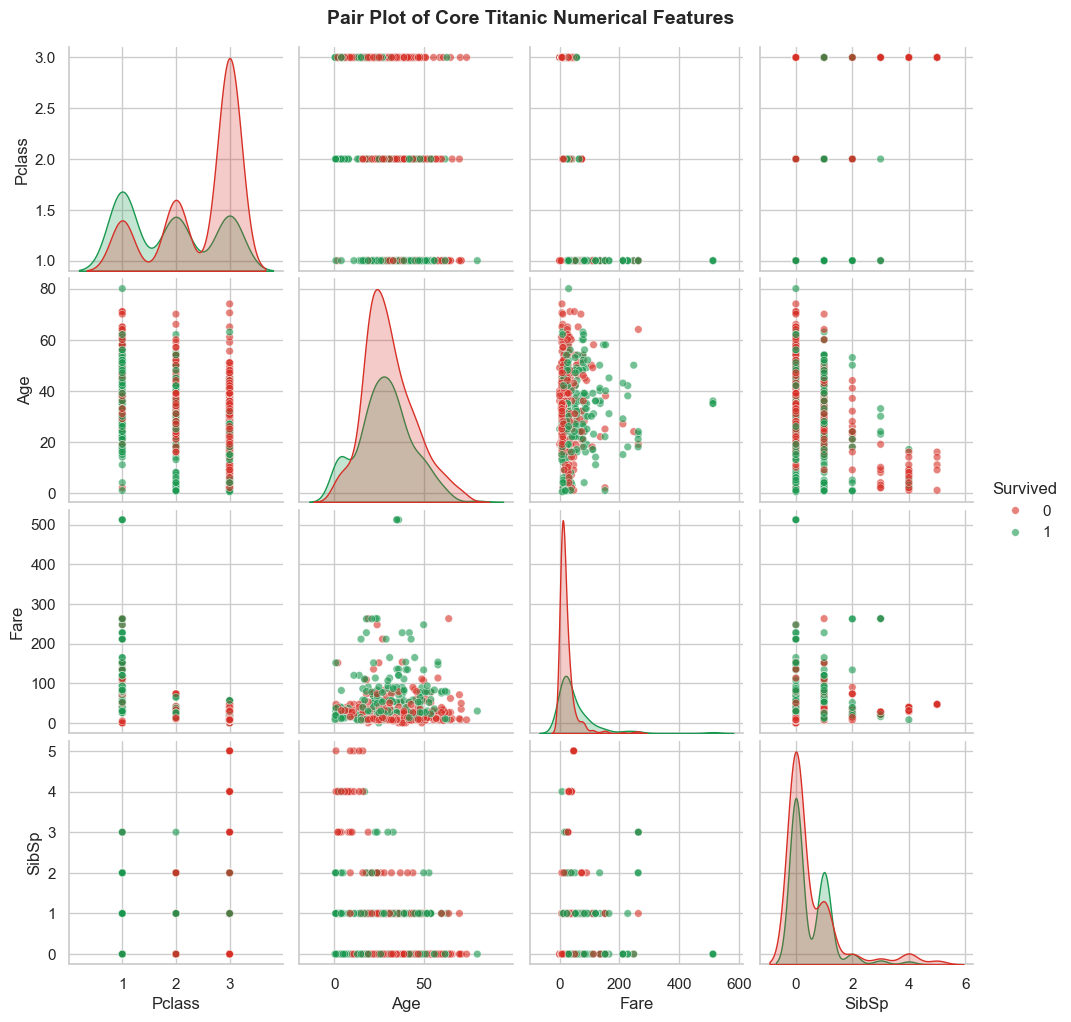

In [5]:
# Select core numerical features
numerical_cols = ['Survived', 'Pclass', 'Age', 'Fare', 'SibSp']

# Generate pairplot colored by Survival status
pairplot_fig = sns.pairplot(
    df[numerical_cols].dropna(), 
    hue='Survived', 
    palette={0: '#d73027', 1: '#1a9850'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)

pairplot_fig.fig.suptitle('Pair Plot of Core Titanic Numerical Features', y=1.02, fontsize=14, weight='bold')
plt.savefig('../../outputs/plots/bivariate_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation
The pair plot immediately surfaces two key patterns:
1. The diagonal KDE for `Fare` shows survivors (green) have a much heavier right tail than non-survivors (red).
2. The `Pclass` scatter panels show survivors heavily concentrated in class 1 (lower numbers), while class 3 is dominated by non-survivors.


## 3. Numerical + Categorical Analysis

In machine learning, we often want to know: **Does a numerical feature differ significantly across classes of a categorical target?**


### 3.1 Bar Plot (`sns.barplot`)

A bar plot computes the **mean** of the numerical variable for each category, with vertical error bars showing the 95% confidence interval.


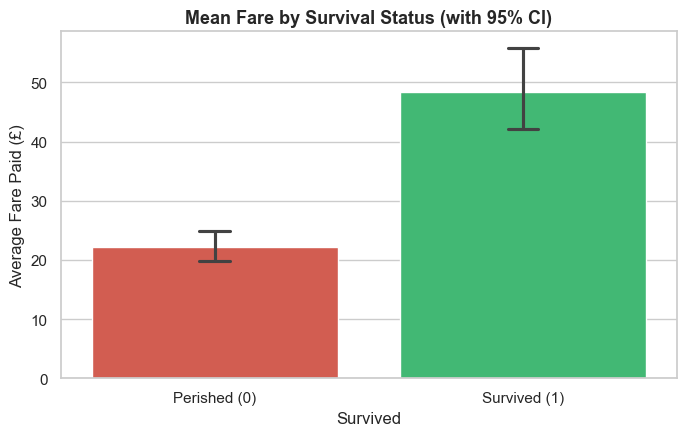

In [6]:
plt.figure(figsize=(7, 4.5))

sns.barplot(
    data=df, 
    x='Survived', 
    y='Fare', 
    palette={0: '#e74c3c', 1: '#2ecc71'},
    hue='Survived',
    legend=False,
    capsize=0.1
)

plt.title('Mean Fare by Survival Status (with 95% CI)', fontsize=13, weight='bold')
plt.xticks([0, 1], ['Perished (0)', 'Survived (1)'])
plt.ylabel('Average Fare Paid (£)')
plt.tight_layout()
plt.show()


### Observation
Survivors paid an average fare of **£48.40**, whereas passengers who perished paid an average of **£22.12**—more than a 2x difference!


### 3.2 Box Plot by Category (`sns.boxplot`)

While a bar plot only shows the mean, a box plot reveals the **entire distribution**: median, quartiles, and individual outliers.


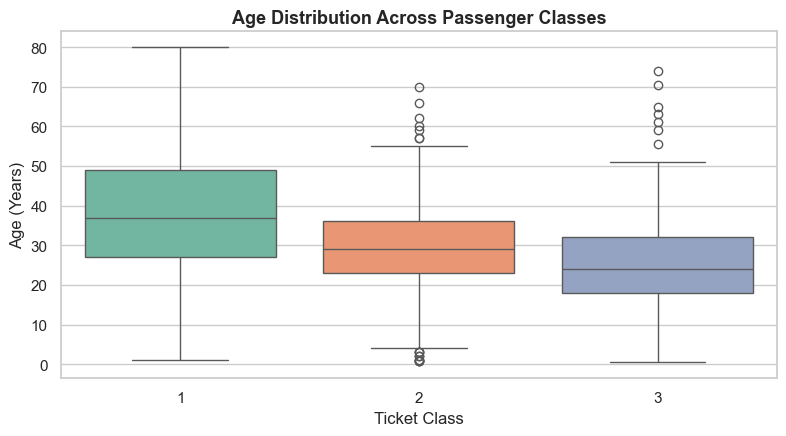

In [7]:
plt.figure(figsize=(8, 4.5))

sns.boxplot(
    data=df, 
    x='Pclass', 
    y='Age', 
    palette='Set2', 
    hue='Pclass', 
    legend=False
)

plt.title('Age Distribution Across Passenger Classes', fontsize=13, weight='bold')
plt.xlabel('Ticket Class')
plt.ylabel('Age (Years)')
plt.tight_layout()
plt.show()


### Observation
- **1st Class:** Median age is **37 years** (older, established, wealthier passengers).
- **2nd Class:** Median age is **29 years**.
- **3rd Class:** Median age is **24 years** (younger laborers, families, and immigrants).
This clear age gradient makes `Pclass` an excellent feature for imputing missing `Age` values later!


### 3.3 Critical Comparison: Bar Plot vs. Box Plot

Why can relying solely on Bar Plots be dangerous?
Let us compare a Bar Plot and a Box Plot of `Fare` across `Pclass`.


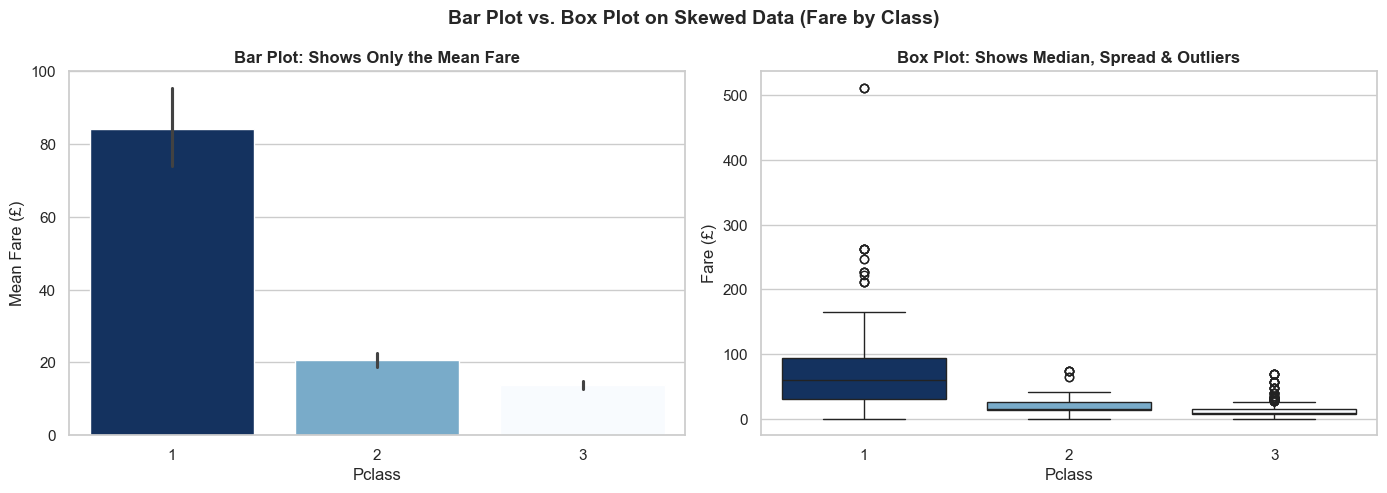

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar Plot (Mean)
sns.barplot(data=df, x='Pclass', y='Fare', ax=ax1, palette='Blues_r', hue='Pclass', legend=False)
ax1.set_title('Bar Plot: Shows Only the Mean Fare', weight='bold')
ax1.set_ylabel('Mean Fare (£)')

# Box Plot (Distribution + Outliers)
sns.boxplot(data=df, x='Pclass', y='Fare', ax=ax2, palette='Blues_r', hue='Pclass', legend=False)
ax2.set_title('Box Plot: Shows Median, Spread & Outliers', weight='bold')
ax2.set_ylabel('Fare (£)')

plt.suptitle('Bar Plot vs. Box Plot on Skewed Data (Fare by Class)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


### Observation & Comparison
- The **Bar Plot** makes 1st class look like passengers routinely paid ~£84.
- The **Box Plot** exposes reality: The median 1st class ticket was actually **£60.29**. The mean of £84 was heavily dragged upward by extreme outliers paying £200 to £512.
- **Rule:** Never use Bar Plots alone on skewed data. Box Plots provide the true distributional ground truth.


### 3.4 Grouped KDE Plot (`sns.kdeplot(hue=...)`)

Comparing continuous probability densities across categories without bin artifacts.


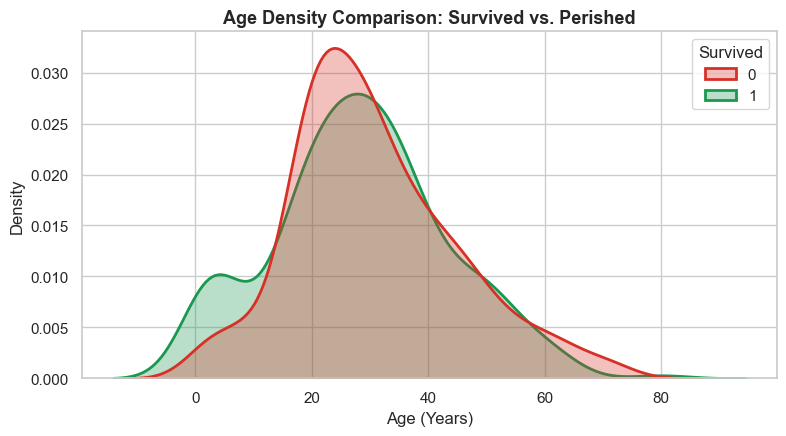

In [9]:
plt.figure(figsize=(8, 4.5))

sns.kdeplot(
    data=df, 
    x='Age', 
    hue='Survived', 
    common_norm=False, 
    palette={0: '#d73027', 1: '#1a9850'},
    fill=True, 
    alpha=0.3,
    linewidth=2
)

plt.title('Age Density Comparison: Survived vs. Perished', fontsize=13, weight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


### Observation
The green curve (survivors) has a noticeable peak between ages 0 and 5, demonstrating that infants and young children were prioritized during lifeboat loading ("women and children first"). Between ages 18 and 35, the red curve (perished) is higher.


## 4. Categorical + Categorical Analysis

When both features are categorical, scatter plots fail because observations stack on top of identical discrete values.
We use **Contingency Tables (`pd.crosstab`)** and **Heatmaps**.


### 4.1 Contingency Table (`pd.crosstab`)

Let us examine the relationship between `Pclass` and `Survived`.


In [10]:
# Raw contingency table
crosstab_raw = pd.crosstab(df['Pclass'], df['Survived'])
crosstab_raw.columns = ['Perished (0)', 'Survived (1)']
crosstab_raw.index = ['1st Class', '2nd Class', '3rd Class']

crosstab_raw


,Perished (0),Survived (1)
1st Class,80,136
2nd Class,97,87
3rd Class,372,119


### 4.2 Why Row Percentages Are More Meaningful Than Raw Counts

Look at the raw survivor counts above:
- 1st Class: **136** survivors
- 3rd Class: **119** survivors

At a glance, 136 and 119 seem very similar!
Does this mean 1st and 3rd class had similar survival outcomes?
**Absolutely not.** Let us normalize by row (`normalize='index'`) to find the **conditional survival probability** within each class.


In [11]:
# Row percentage crosstab
crosstab_pct = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
crosstab_pct.columns = ['Perished (%)', 'Survived (%)']
crosstab_pct.index = ['1st Class', '2nd Class', '3rd Class']

crosstab_pct.round(2)


,Perished (%),Survived (%)
1st Class,37.04,62.96
2nd Class,52.72,47.28
3rd Class,75.76,24.24


### Observation
- 1st Class survival rate: **62.96%**
- 2nd Class survival rate: **47.28%**
- 3rd Class survival rate: **24.24%**

**The Truth:** A 1st class passenger was **2.6 times more likely to survive** than a 3rd class passenger.
Raw counts distorted reality because 3rd class had far more total passengers (491) than 1st class (216).


### 4.3 Percentage Heatmap (`sns.heatmap`)

A heatmap visualizes cross-tabulated proportions with intuitive color intensity.


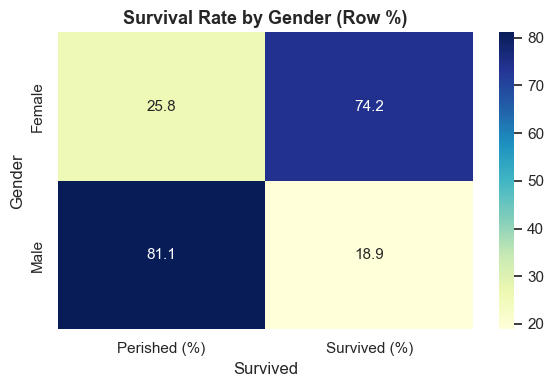

In [12]:
# Crosstab of Sex vs Survived (percentages)
gender_survival_pct = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100

plt.figure(figsize=(6, 4))
sns.heatmap(
    gender_survival_pct, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGnBu', 
    cbar=True,
    xticklabels=['Perished (%)', 'Survived (%)'],
    yticklabels=['Female', 'Male']
)

plt.title('Survival Rate by Gender (Row %)', fontsize=13, weight='bold')
plt.ylabel('Gender')
plt.tight_layout()

# Save plot
plt.savefig('../../outputs/plots/bivariate_crosstab_gender_survival.png', dpi=150)
plt.show()


### Observation
- **Female survival rate:** **74.2%**
- **Male survival rate:** **18.9%**
Gender is the single most powerful bivariate predictor of survival on the Titanic.


### 4.4 ClusterMap (`sns.clustermap`)

A **ClusterMap** performs hierarchical clustering on both the rows and columns of a matrix, reorganizing categories so that similar groups appear adjacent to each other.


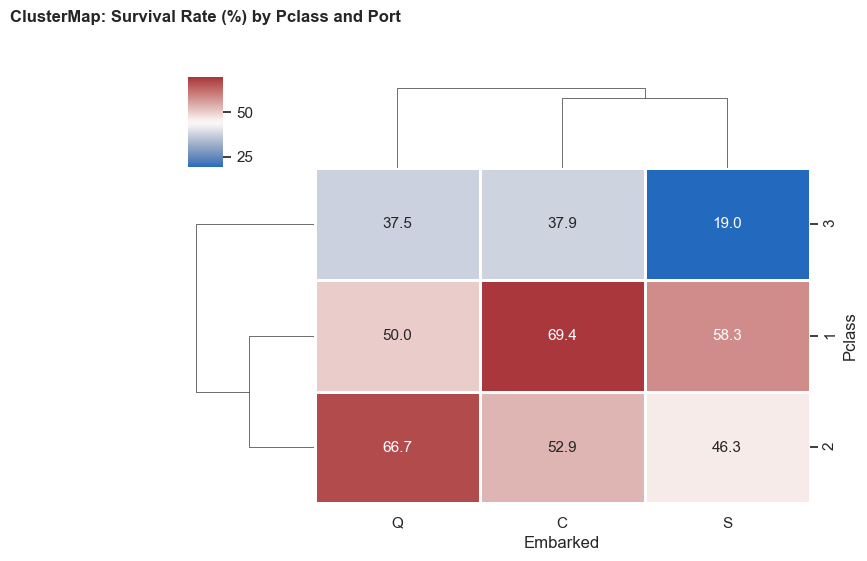

In [13]:
# Multi-category survival rate cross-tabulation: (Pclass x Sex) vs Embarked
pivot_table = df.pivot_table(index='Pclass', columns='Embarked', values='Survived', aggfunc='mean') * 100

# Clustermap showing which class/port combinations behave similarly
sns.clustermap(
    pivot_table, 
    annot=True, 
    fmt='.1f', 
    cmap='vlag', 
    figsize=(7, 5),
    linewidths=1
)

plt.title('ClusterMap: Survival Rate (%) by Pclass and Port', pad=40, weight='bold')
plt.show()


### Observation
The dendrogram links classes 2 and 3 together first because their survival rates are consistently lower than class 1 across all embarkation ports.


### Key Takeaways
1. Numerical + Numerical: Use scatter plots to diagnose relationship types (linear, non-linear, null) and pair plots for comprehensive surveys.
2. Numerical + Categorical: Prefer box plots over bar plots to inspect full distributions and avoid outlier distortion.
3. Categorical + Categorical: Never rely solely on raw contingency counts; always normalize by row (`normalize='index'`) to prevent unequal group size bias.
